---
title: Frequency Analysis
jupyter: python3
---


Using polars to do basic corpus searching


In [ ]:
import polars as pl
import polars.selectors as cs
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
bnc = pl.read_parquet("../../bnc.parquet")
bnc.head(10)

## Token frequency

### Absolute frequency

In [ ]:
abs_freq = bnc['token'].value_counts(sort=True)
abs_freq.head()

### Relative frequency

In [ ]:
rel_freq = ( bnc['token']
             .value_counts(normalize=True, sort=True)
             .with_columns(pl.col('proportion')*100000)
             )
rel_freq.head()

### Zipf's Law

In [ ]:
zipf = ( bnc['token'].str.to_lowercase()
         .value_counts(sort=True)
         .with_row_index("rank", offset=1)
         )
sns.lineplot(data=zipf.head(50), x="rank", y="count")

In [ ]:
plt.loglog()
sns.lineplot(data=zipf, x="rank", y="count")

## Dispersion

### Range2

In [ ]:
n_file_ids = bnc.select(pl.col('file_id').n_unique()).item()
r2 = ( bnc.group_by('lemma')
       .agg((pl.col('file_id').n_unique()/n_file_ids*100).alias('r2'))
       .sort(by="r2", descending=True)
       )
r2.head()

Brezina pg. 26

In [22]:
the = (
    bnc.filter(mode="spoken")
    .group_by("file_id")
    .agg(
        (
            pl.col("lemma").len().alias("n"),
            (pl.col("lemma") == "the").sum().alias("the"),
            (pl.col("lemma") == "i").sum().alias("i"),
            (pl.col("lemma") == "you").sum().alias("you"),
        )
    )
    .select("file_id", (cs.numeric().exclude("n") / pl.col("n") * 10000))
    .sort(by="file_id")
)

the.head(10)

file_id,the,i,you
str,f64,f64,f64
"""D8Y""",351.247854,150.534795,143.932391
"""D90""",418.747599,257.395313,142.14368
"""D91""",466.304523,371.645243,173.721293
"""D92""",551.431601,466.59597,254.506893
"""D94""",91.743119,581.039755,183.486239
"""D95""",404.672276,248.007086,177.701506
"""D96""",509.304603,254.652302,264.446621
"""D97""",283.304076,394.480203,184.318315
"""DCH""",277.288276,273.660205,137.866694


<Axes: xlabel='Count', ylabel='the'>

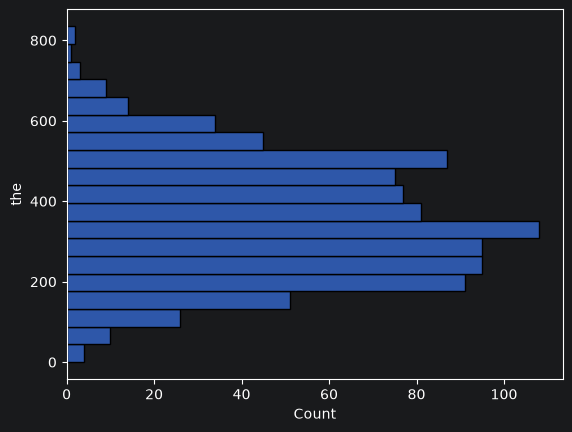

In [23]:
sns.histplot(the.to_pandas(), y="the")

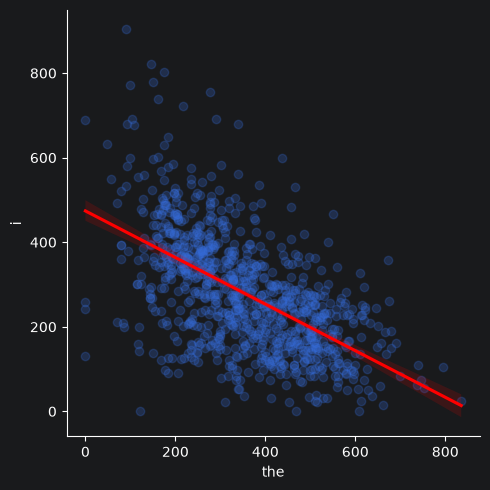

In [24]:
sns.lmplot(
    the.to_pandas(),
    x="the",
    y="i",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"},
)

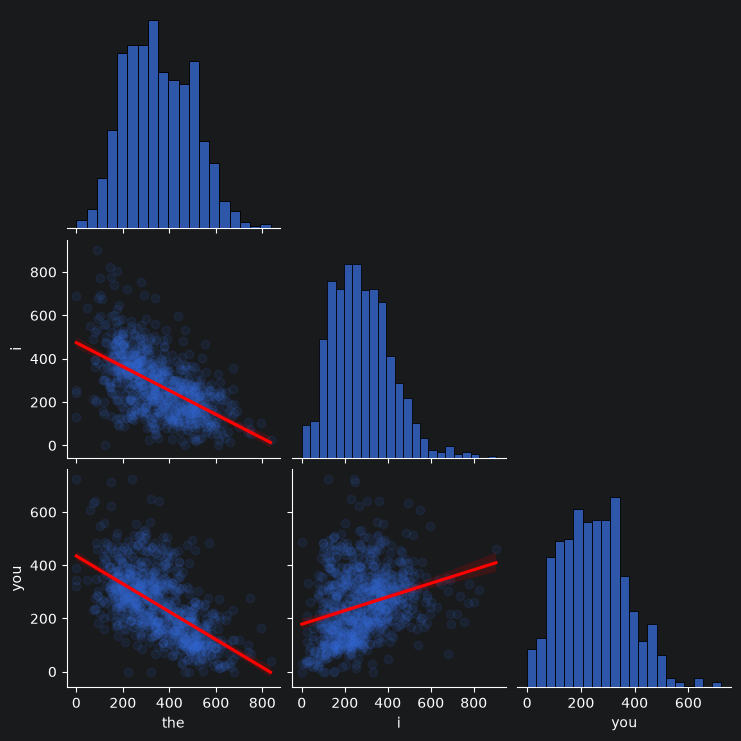

In [26]:
sns.pairplot(
    the.to_pandas(),
    vars=["the", "i", "you"],
    kind="reg",
    corner=True,
    plot_kws={"scatter_kws": {"alpha": 0.1}, "line_kws": {"color": "red"}},
)

In [27]:
hits = bnc.filter(
    pl.col("lemma").is_in(["very", "really", "rather", "quite"]), pl.col("tag") == "AV0"
)
counts = (
    hits.group_by("lemma", "text_type")
    .agg(pl.len().alias("count"))
    .with_columns(
        (pl.col("count") / pl.col("count").sum().over("text_type") * 100).alias("pct")
    )
)
counts

lemma,text_type,count,pct
str,str,u32,f64
"""really""","""NONAC""",5521,11.768342
"""quite""","""NONAC""",7143,15.225732
"""quite""","""ACPROSE""",3823,13.236618
"""very""","""NEWS""",7406,51.61695
"""very""","""OTHERPUB""",20937,51.66058
…,…,…,…
"""rather""","""OTHERSP""",2585,7.103209
"""very""","""ACPROSE""",12769,44.210927
"""very""","""CONVRSN""",6445,31.972418


In [28]:
hits = bnc.filter(pl.col("lemma").is_in(["very", "really"]))

ratio = (
    hits.group_by("text_type")
    .agg(
        ((pl.col("token") == "very").sum() / (pl.col("token") == "really").sum()).alias(
            "ratio"
        )
    )
    .sort(by="ratio")
)
ratio

text_type,ratio
str,f64
"""CONVRSN""",0.71413
"""FICTION""",2.062849
"""OTHERSP""",2.117939
"""NEWS""",3.091058
"""OTHERPUB""",3.228697
"""UNPUB""",4.162037
"""NONAC""",4.347436
"""ACPROSE""",6.33641
